# Notebook for preprocessing CTE ocean fluxes



Step 1: Fill zeros (=land) in the coarse resolution data with linear interpolation

Step 2: Perform "naive interpolation" to the filled data (output of step 2) to obtain the final high-resolution dataset
 
* Steps of naive interpolation
1) First linear interpolation on the filled data
2) Mask out the 0.1 x 0.1 resolution landcells to zero



In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import os
from global_land_mask import globe

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs



In [2]:
def select_area(aoi, ds):
    # Determine the dimension names for latitude and longitude
    lat_name = 'lat' if 'lat' in ds.dims else 'latitude'
    lon_name = 'lon' if 'lon' in ds.dims else 'longitude'
    
    # Select the area based on the area of interest
    area_subset = ds.sel({lon_name: slice(aoi[0], aoi[1]),
                          lat_name: slice(aoi[2], aoi[3])})
    return area_subset

def extract_period(fname):
    period= int(fname[-9:-3])
    return period

def extract_year(fname):
    year = int(fname[-9:-5])
    return year

def high_res_lon(data):
    lon = data["longitude"].values
    n_lon = len(lon)
    new_lon = np.linspace(lon.min()-0.05, lon.max()+0.05, n_lon * 2)

    return new_lon


def create_lsm_like(data):
    lon = data["longitude"].values
    lat = data["latitude"].values
    longrid, latgrid = np.meshgrid(lon,lat)
    lsm = globe.is_land(latgrid, longrid)
    return lsm

import numpy as np
import xarray as xr
from scipy.interpolate import griddata


def interpolate_zeros(data, lat, lon, method='linear'):
    """
    Interpolates zero values in a 2D array using `griddata`.

    Parameters:
    - data (2D array): The variable data at a single time step.
    - lat (2D array): Latitude values.
    - lon (2D array): Longitude values.
    - method (str): Interpolation method ('linear', 'nearest', or 'cubic').

    Returns:
    - (2D array): The data with zeros replaced by interpolated values.
    """
    # Convert zeros to NaNs for interpolation
    data_with_nan = np.where(data == 0, np.nan, data)

    # Flatten arrays for interpolation
    points = np.column_stack([lat.ravel(), lon.ravel()])
    values = data_with_nan.ravel()

    # Identify valid (non-NaN) points
    valid_mask = ~np.isnan(values)
    valid_points = points[valid_mask]
    valid_values = values[valid_mask]

    if len(valid_values) == 0:
        return data  # Return original if no valid values exist

    # Perform interpolation
    interpolated_values = griddata(
        valid_points, valid_values, points, method=method, fill_value=np.nan
    )

    # Reshape back to the original shape
    interpolated_grid = interpolated_values.reshape(data.shape)

    # Replace zeros with interpolated values
    return np.where(data == 0, interpolated_grid, data)

def interpolate_and_replace(dataset, variable_name, method='linear'):
    """
    Replace all 0 values in an xarray dataset's variable with interpolated values 
    based on latitude and longitude, vectorized over the time dimension.

    Parameters:
    - dataset: xarray.Dataset
        The dataset containing the variable to be interpolated.
    - variable_name: str
        The name of the variable to process.
    - method: str, optional
        The interpolation method ('linear', 'nearest', or 'cubic').
        Default is 'linear'.

    Returns:
    - xarray.Dataset
        A new dataset with interpolated values replacing zeros.
    """
    # Ensure the dataset has a time dimension
    if 'time' not in dataset[variable_name].dims:
        raise ValueError("The dataset must have a 'time' dimension.")

    # Get latitude and longitude
    lat = dataset['latitude']
    lon = dataset['longitude']

    # Convert to 2D grids
    lon_grid, lat_grid = np.meshgrid(lon, lat)
   

    # Ensure lat/lon grids are DataArrays with the correct dimensions
    lat_grid = xr.DataArray(lat_grid, dims=('latitude', 'longitude'))
    lon_grid = xr.DataArray(lon_grid, dims=('latitude', 'longitude'))

    # Use apply_ufunc to efficiently map function over time
    new_var = xr.apply_ufunc(
    interpolate_zeros, 
    dataset[variable_name],  # 1st argument: Data variable
    lat_grid,                # 2nd argument: Latitude grid
    lon_grid,                # 3rd argument: Longitude grid
    kwargs={'method': method},
    input_core_dims=[
        ['latitude', 'longitude'],  # For the variable being interpolated
        ['latitude', 'longitude'],  # For latitude grid
        ['latitude', 'longitude']   # For longitude grid
    ],  
    output_core_dims=[['latitude', 'longitude']],  
    vectorize=True,  
    dask="parallelized",  
    output_dtypes=[dataset[variable_name].dtype]  
    )

    # Return a new dataset with updated variable
    return dataset.assign({variable_name: new_var})




def naive_interp(ds):
    new_lon = high_res_lon(ds)
    highres_ds = ds.interp({"longitude": new_lon})
    lsm = create_lsm_like(highres_ds)
    highres_ds["emi_ocn"].values[:,lsm] = 0
    return highres_ds

In [11]:
DATA_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/raw_data/"

filenames = [os.path.join(DATA_PATH,f) for f in os.listdir(DATA_PATH) if f.endswith(".nc")]

#ds = xr.open_dataset(filenames[-1])
ds = xr.open_dataset("/home/pietaril/Documents/data/CTE_ocean_fluxes/raw_data/ocean.202408.nc")
ds


<xarray.Dataset>
Dimensions:    (time: 744, longitude: 250, latitude: 390)
Coordinates:
  * time       (time) datetime64[ns] 2024-08-01 ... 2024-08-31T23:00:00
  * longitude  (longitude) float64 -14.9 -14.7 -14.5 -14.3 ... 34.5 34.7 34.9
  * latitude   (latitude) float64 33.05 33.15 33.25 33.35 ... 71.75 71.85 71.95
Data variables:
    ocean      (time, latitude, longitude) float32 ...
Attributes: (12/18)
    CDI:                        Climate Data Interface version 2.0.6 (https:/...
    Conventions:                CF-1.8
    disclaimer:                 This data belongs to the CarbonTracker project
    CDO:                        Climate Data Operators version 2.0.6 (https:/...
    source:                     CTE-HR 1.0. Created using the code from https...
    institution:                Wageningen University, department of Meteorol...
    ...                         ...
    geospatial_lat_resolution:  0.1 degree
    geospatial_lon_resolution:  0.2 degree
    keywords:                   carbon flux
    license:                    CC-BY-4.0
    nominal_resolution:         0.1x0.2 degree
    comment:                    Hourly ocean fluxes, based on a climatology o...

# Check time unit

In [ ]:
import netCDF4 as nc

data_nc = nc.Dataset(filenames[0], 'r')
data_nc.variables

# 1st step: compute and save the coarse resolution padded grids
* i.e. 0's replaced by linear interpolation
* due to slowness & to check the padded files
* The save to netcdf part of this step can later be removed and just immeadiately use the naive_interp - function to compute the "final" product and save that

In [4]:
import dask
from dask.distributed import Client
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 30.76 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44877,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 30.76 GiB
Comm: tcp://127.0.0.1:42227,Total threads: 2
Dashboard: http://127.0.0.1:42993/status,Memory: 7.69 GiB
Nanny: tcp://127.0.0.1:41597,


In [6]:
client.shutdown()

2025-04-17 15:50:22,325 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [3]:

DATA_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/raw_data/"
FILLED_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/processed/padded/"


#sort the filenames by time so no need to sort later
fnames = [os.path.join(DATA_PATH,f) for f in os.listdir(DATA_PATH) if f.endswith(".nc")]
df_filenames = pd.DataFrame({'filename': fnames})
df_filenames['period'] = df_filenames['filename'].apply(extract_period)
df_filenames['year'] = df_filenames['filename'].apply(extract_year)
df_filenames = df_filenames.sort_values('period').reset_index(drop=True)



# Open all input files for the year
for year in range(2023, 2024):
    files_1year = df_filenames[df_filenames['year']==year]['filename'].to_list()
    assert len(files_1year)==12
    datasets = [xr.open_dataset(file) for file in files_1year]
   
    #the numerical values in the latitude/longitude grids differ a little between datasets (less than the resolution, probably due to rounding errors) so
    # need to fix a common grid before concatenation 
    common_lat = datasets[0]['latitude']
    common_lon = datasets[0]['longitude']

    # Replace the latitude and longitude coordinates in each dataset
    standardized_datasets = []
    for ds in datasets:
        ds = ds.assign_coords(latitude=common_lat, longitude=common_lon)
        standardized_datasets.append(ds)

    # Concatenate the standardized datasets along the time dimension
    ds_1year = xr.concat(standardized_datasets, dim="time")



 

    #concatenate the files to a single dataset along time dimension
    #ds_1year = xr.concat(datasets, dim="time")
  
    #convert fluxes to float64
    # ds_1year["ocean"] = ds_1year["ocean"].astype("float64")
    # rename_map = {
    #     "ocean" : "emi_ocn",
    # }

    #ds_1year = ds_1year.rename(rename_map)

    # padded_ds = interpolate_and_replace(ds_1year, "emi_ocn")
    # padded_ds.attrs = {}
    # padded_ds.attrs.update({"description": "Ocean CO2 gridded total yearly fluxes from CTE-HR, 0:s filled by linear interpolation, res 0.1 x 0.2",
    #                         "units": "mol m-2 s-1"})

    # outname = f"ocean_flux_coarse_padded_{year}.nc"

    # padded_ds.to_netcdf(os.path.join(FILLED_PATH, outname), encoding={'time':{'units': "days since 1900-01-01"}})
    #for ds in datasets:
        #ds.close()


In [4]:
ds_1year

<xarray.Dataset>
Dimensions:    (time: 8760, longitude: 250, latitude: 390)
Coordinates:
  * time       (time) datetime64[ns] 2023-01-01 ... 2023-12-31T23:00:00
  * longitude  (longitude) float64 -14.9 -14.7 -14.5 -14.3 ... 34.5 34.7 34.9
  * latitude   (latitude) float64 33.05 33.15 33.25 33.35 ... 71.75 71.85 71.95
Data variables:
    ocean      (time, latitude, longitude) float32 -7.073e-08 ... -4.921e-08
Attributes: (12/18)
    CDI:                        Climate Data Interface version 2.1.1 (https:/...
    Conventions:                CF-1.8
    disclaimer:                 This data belongs to the CarbonTracker project
    CDO:                        Climate Data Operators version 2.1.1 (https:/...
    source:                     CTE-HR 1.0. Created using the code from https...
    institution:                Wageningen University, department of Meteorol...
    ...                         ...
    geospatial_lat_resolution:  0.1 degree
    geospatial_lon_resolution:  0.2 degree
    keywords:                   carbon flux
    license:                    CC-BY-4.0
    nominal_resolution:         0.1x0.2 degree
    comment:                    Hourly ocean fluxes, based on a climatology o...

In [20]:
np.zeros(390).shape

(390,)

AttributeError: 'function' object has no attribute 'histogram'

## Check the computed files

In [3]:
ds = xr.open_dataset("/home/pietaril/Documents/data/CTE_ocean_fluxes/processed/padded/ocean_flux_coarse_padded_2023.nc")
ds["emi_ocn"]


<xarray.DataArray 'emi_ocn' (time: 8760, latitude: 390, longitude: 250)>
[854100000 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 2023-01-01 ... 2023-12-31T23:00:00
  * latitude   (latitude) float64 33.05 33.15 33.25 33.35 ... 71.75 71.85 71.95
  * longitude  (longitude) float64 -14.9 -14.7 -14.5 -14.3 ... 34.5 34.7 34.9

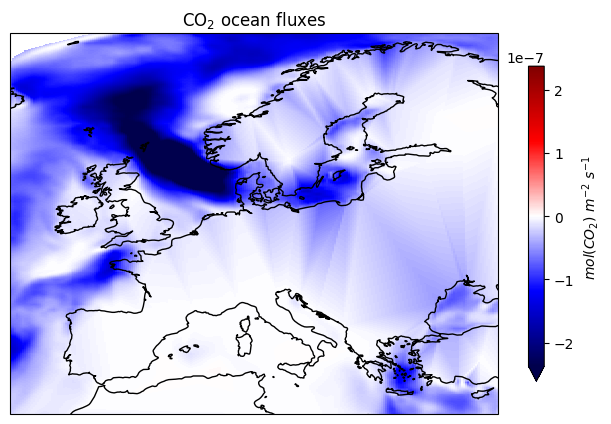

In [5]:
cbar_label = "$mol(CO_2)$ $m^{-2}$ $s^{-1}$"
variable = "emi_ocn"
cbar_shrink = 0.7
cmap = mpl.colormaps["seismic"]
suptitle="CO$_2$ ocean fluxes"




fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

ds[variable][3005,:,:].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.set_title(suptitle)
plt.tight_layout()
plt.draw()
figpath = "/home/pietaril/Documents/plots/CTE_ocean/"
figname = f"CTE_ocean_scandinavia_mean_CO2_flux_2018_2021.png"
#plt.savefig(figpath+figname)
plt.draw()

In [9]:
ds2 = xr.open_dataset("/home/pietaril/Documents/data/CTE_ocean_fluxes/processed/padded/ocean_flux_coarse_padded_2022.nc")
ds2

<xarray.Dataset>
Dimensions:    (time: 8760, longitude: 250, latitude: 390)
Coordinates:
  * time       (time) datetime64[ns] 2022-01-01 ... 2022-12-31T23:00:00
  * longitude  (longitude) float64 -14.9 -14.7 -14.5 -14.3 ... 34.5 34.7 34.9
  * latitude   (latitude) float64 33.05 33.15 33.25 33.35 ... 71.75 71.85 71.95
Data variables:
    emi_ocn    (time, latitude, longitude) float64 ...
Attributes:
    description:  Ocean CO2 gridded total yearly fluxes from CTE-HR, 0:s fill...
    units:        mol m-2 s-1

# Interpolating the filled coarse data done with separate .py script 
 * Uses so much memory that needed to do this in LUMI

In [ ]:
COARSE_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_kg_m-2_hr-1/"
FILLED_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_filled_kg_m-2_hr-1/"
HIGHRES_PATH =  "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/highres_kg_m-2_hr-1/"

coarse_fnames = [os.path.join(COARSE_PATH,f) for f in os.listdir(COARSE_PATH) if f.endswith(".nc")]
fnames_padded =  [os.path.join(FILLED_PATH,f) for f in os.listdir(FILLED_PATH) if f.endswith(".nc")]
highres_fnames =  [os.path.join(HIGHRES_PATH,f) for f in os.listdir(HIGHRES_PATH) if f.endswith(".nc")]
coarse_fnames.sort()
fnames_padded.sort()
highres_fnames.sort()

ds0 = xr.open_dataset(coarse_fnames[0])
ds1 = xr.open_dataset(fnames_padded[0])
ds2 = xr.open_dataset(highres_fnames[0])

t = 4000
ds0t = ds0.isel({"time":t})
ds1t = ds1.isel({"time": t})
ds2t = ds2.isel({"time": t})

titles = ["orig","orig padded", "highres"]
datas = [ds0t, ds1t, ds2t]
cbar_label= "$kg(CO_2)$ $m^{-2}$ $hr^{-1}$"
cbar_shrink = 0.4
cmap = mpl.colormaps["seismic"]

fig, axs = plt.subplots(1,3, figsize=(15,13), subplot_kw=dict(projection=ccrs.PlateCarree()))
for i, ax in enumerate(axs.flatten()):
    data = datas[i]
    
    data["emi_ocn"].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
    ax.coastlines()
    ax.gridlines()#draw_labels=True)
    ax.set_title(titles[i])
#ax.set_title(suptitle)
plt.tight_layout()
plt.draw()

# Test with smaller area

In [4]:
FILLED_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_filled_kg_m-2_hr-1/"
fnames_padded =  [os.path.join(FILLED_PATH,f) for f in os.listdir(FILLED_PATH) if f.endswith(".nc")]
fnames_padded.sort()
ds = xr.open_dataset(fnames_padded[0])
aoi_subset = [21, 25, 57, 62] 
ds_small = select_area(aoi_subset, ds)
hr_small = naive_interp(ds_small)


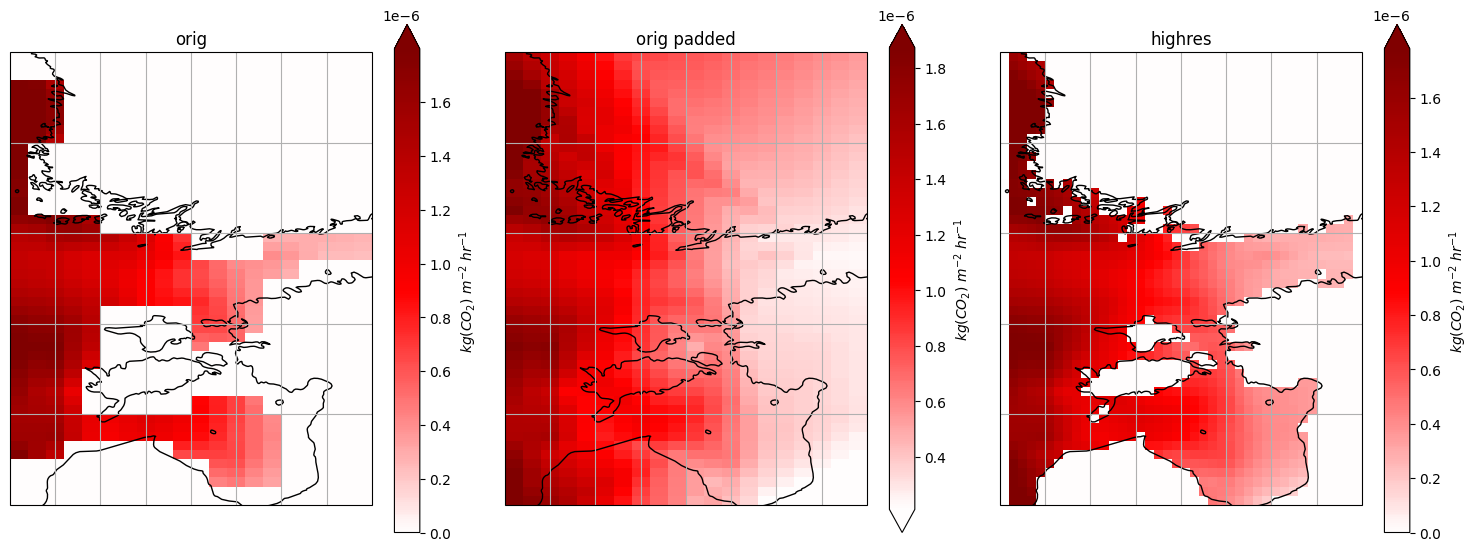

In [11]:
COARSE_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_kg_m-2_hr-1/"
FILLED_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_filled_kg_m-2_hr-1/"

coarse_fnames = [os.path.join(COARSE_PATH,f) for f in os.listdir(COARSE_PATH) if f.endswith(".nc")]
coarse_fnames.sort()
filled_fnames = [os.path.join(FILLED_PATH,f) for f in os.listdir(FILLED_PATH) if f.endswith(".nc")]
filled_fnames.sort()


t = 1000
ds0 = xr.open_dataset(coarse_fnames[0])
ds0 = select_area(aoi_subset, ds0)
ds0t = ds0.isel({"time": t})

ds1t = ds_small.isel({"time":t})

ds2t = hr_small.isel({"time": t})

titles = ["orig","orig padded", "highres"]
datas = [ds0t, ds1t, ds2t]
cbar_label= "$kg(CO_2)$ $m^{-2}$ $hr^{-1}$"
cbar_shrink = 0.4
cmap = truncate_colormap(mpl.colormaps["seismic"], minval=0.5)

fig, axs = plt.subplots(1,3, figsize=(15,13), subplot_kw=dict(projection=ccrs.PlateCarree()))
for i, ax in enumerate(axs.flatten()):
    data = datas[i]
    
    data["emi_ocn"].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
    ax.coastlines()
    ax.gridlines()#draw_labels=True)
    ax.set_title(titles[i])
#ax.set_title(suptitle)
plt.tight_layout()
plt.draw()

# Compute gridded yearly totals

In [14]:
def hourly_kgm2hr_to_gm2yr(ds, var):
    """Unit conversion for hourly time resolution data from unit kg/m2/hr to g/m2/yr"""

    #hourly to yearly
    out = ds[var].sum(dim="time")
    #kg to g
    out = out*1000
    #pick the first timestamp as the time axis value to represent the year
    time = ds["time"].values[0]
    out = out.to_dataset()
    out.coords["time"] = (time) 
    out = out.expand_dims("time")
    return out


1

## Totals for lower resolution

In [11]:
FLUX_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_kg_m-2_hr-1/"
YEARLY_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_g_m-2_yr/"
aoi = [-12, 35, 35, 72]

fnames_1year = [os.path.join(FLUX_PATH,f) for f in os.listdir(FLUX_PATH) if f.endswith(".nc")]
for fname in fnames_1year:
    year = fname[-7:-3]
    ds = xr.open_dataset(fname)
    gm2yr = hourly_kgm2hr_to_gm2yr(ds, "emi_ocn")
    gm2yr.attrs = {}
    gm2yr.attrs.update({"description": "Ocean CO2 gridded total yearly fluxes from CTE-HR with resolution 0.1 x 0.2",
                            "units": "g m-2 yr-1"})

    outname = f"ocean_gridded_yearly_tot_flux_coarse_{year}.nc"

    gm2yr.to_netcdf(os.path.join(YEARLY_PATH, outname), encoding={'time':{'units': "days since 1900-01-01"}})
    

## Gridcell-totals for data interpolated to higher resolution 

In [15]:
FLUX_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/highres_kg_m-2_hr-1/"
YEARLY_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/highres_g_m-2_yr/"
aoi = [-12, 35, 35, 72]

fnames_1year = [os.path.join(FLUX_PATH,f) for f in os.listdir(FLUX_PATH) if f.endswith(".nc")]
for fname in fnames_1year:
    year = fname[-7:-3]
    ds = xr.open_dataset(fname)
    gm2yr = hourly_kgm2hr_to_gm2yr(ds, "emi_ocn")
    gm2yr.attrs = {}
    gm2yr.attrs.update({"description": "Ocean CO2 gridded total yearly fluxes from CTE-HR interpolated to resolution 0.1 x 0.1",
                            "units": "g m-2 yr-1"})

    outname = f"ocean_gridded_yearly_tot_flux_highres_{year}.nc"

    gm2yr.to_netcdf(os.path.join(YEARLY_PATH, outname), encoding={'time':{'units': "days since 1900-01-01"}})



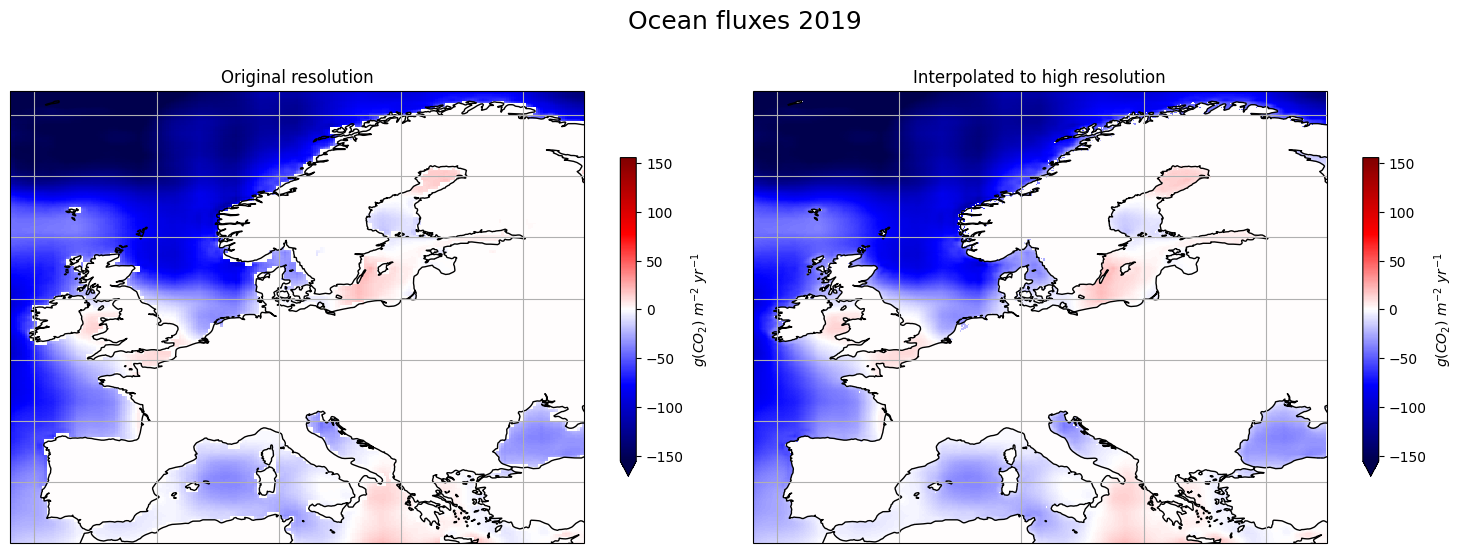

In [ ]:
COARSE_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_g_m-2_yr/"
HIGHRES_PATH =  "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/highres_g_m-2_yr/"

coarse_fnames = [os.path.join(COARSE_PATH,f) for f in os.listdir(COARSE_PATH) if f.endswith(".nc")]
highres_fnames =  [os.path.join(HIGHRES_PATH,f) for f in os.listdir(HIGHRES_PATH) if f.endswith(".nc")]
coarse_fnames.sort()
highres_fnames.sort()

ds0 = xr.open_dataset(coarse_fnames[1])
ds1 = xr.open_dataset(highres_fnames[1])
assert ds0.time.dt.year.data[0] == ds1.time.dt.year.data[0]

t = 0
ds0t = ds0.isel({"time":t})
ds1t = ds1.isel({"time": t})


titles = ["Original resolution","Interpolated to high resolution"]
datas = [ds0t, ds1t]
cbar_label= "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
year = ds0.time.dt.year.data[0]
suptitle = f"Ocean fluxes {year}"
cbar_shrink = 0.6
cmap = mpl.colormaps["seismic"]

fig, axs = plt.subplots(1,2, figsize=(15,6), subplot_kw=dict(projection=ccrs.PlateCarree()))
for i, ax in enumerate(axs.flatten()):
    data = datas[i]
    
    data["emi_ocn"].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
    ax.coastlines()
    #ax.gridlines()#draw_labels=True)
    ax.set_title(titles[i])
plt.suptitle(suptitle, fontsize = 18)
plt.tight_layout()
plt.draw()

In [13]:
HIGHRES_PATH =  "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/highres_g_m-2_yr/"

fnames_yearly = [os.path.join(HIGHRES_PATH, f) for f in os.listdir(HIGHRES_PATH)]
yearly_datasets = [xr.open_dataset(f) for f in fnames_yearly]
#combine the yearly fluxgrids to a single dataset
ds_allyears = xr.concat(yearly_datasets, dim="time") 
ds_allyears = ds_allyears.sortby("time")

aoi_scand = [2, 31.5, 52.5, 72]

scand = select_area(aoi_scand, ds_allyears)
scand_ave = scand.mean(dim="time")

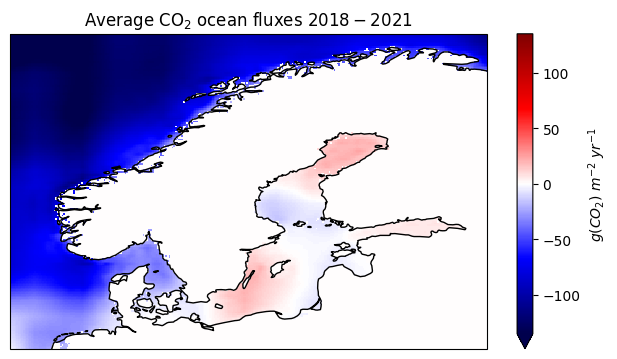

In [19]:
from truncate_colormap import truncate_colormap

cbar_label = "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
variable = "emi_ocn"
cbar_shrink = 0.7
cmap = mpl.colormaps["seismic"]
suptitle="Average CO$_2$ ocean fluxes $2018-2021$"




fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))

scand_ave[variable].plot.pcolormesh(ax=ax, 
                                      robust=True, cmap=cmap,
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))
ax.coastlines()
ax.set_title(suptitle)
plt.tight_layout()
plt.draw()
figpath = "/home/pietaril/Documents/plots/CTE_ocean/"
figname = f"CTE_ocean_scandinavia_mean_CO2_flux_2018_2021.png"
plt.savefig(figpath+figname)
plt.draw()

In [26]:
ds0.time.dt.year.data[0]

2019

## Kiiminki area plots for Tuula

In [36]:
aoi_kii_larger = [21.0, 26.5, 63.9, 70] #[22.5, 28.5, 64, 66.5] 
HIGHRES_PATH =  "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/highres_g_m-2_yr/"


fnames_yearly = [os.path.join(HIGHRES_PATH, f) for f in os.listdir(HIGHRES_PATH)]
yearly_datasets = [xr.open_dataset(f) for f in fnames_yearly]
#combine the yearly fluxgrids to a single dataset
ds_allyears = xr.concat(yearly_datasets, dim="time") 
ds_allyears = ds_allyears.sortby("time")

#ave = ds_allyears.mean(dim="time")

kii = select_area(aoi_kii_larger, ds_allyears)
ave = kii.mean(dim="time")

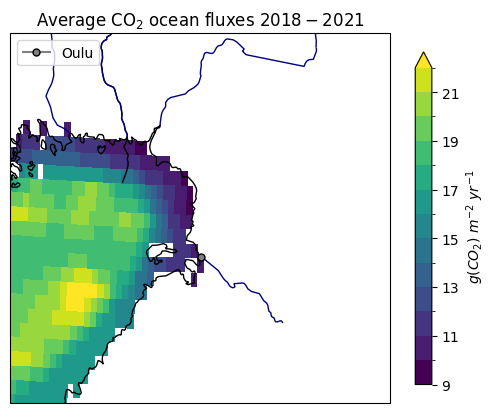

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import MultipleLocator


from truncate_colormap import truncate_colormap
suptitle="Average CO$_2$ ocean fluxes $2018-2021$"
cmap = mpl.colormaps["viridis"] #truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
cbar_shrink = 0.9
cbar_label = "$g(CO_2)$ $m^{-2}$ $yr^{-1}$"
extent = [22.5, 28.5, 64, 66.5]
ds = ave["emi_ocn"]

# Set up the map with a Plate Carree projection
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.epsg('3067')})
ax.set_extent(extent, crs=ccrs.PlateCarree())  # Central Finland area

# Add features such as borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle='-')
ax.add_feature(cfeature.COASTLINE)

# Add rivers
ax.add_feature(cfeature.RIVERS, edgecolor='navy')

# Add a dot for Oulu
oulu_lat, oulu_lon = 65.0121, 25.4651  # Latitude and Longitude of Oulu
ax.plot(oulu_lon, oulu_lat, color='grey', markeredgecolor='black', marker='o', markersize=5, label='Oulu', transform=ccrs.PlateCarree() )

ds.where(ds>0).plot(ax=ax, cmap=cmap, transform = ccrs.PlateCarree(), levels=np.arange(int(ds.where(ds>0).min()), int(ds.max()), 1),
                                       cbar_kwargs=dict(label=cbar_label, shrink=cbar_shrink))

# Add a legend
ax.legend(loc='upper left')
ax.set_title(suptitle)
figpath = "/home/pietaril/Documents/plots/Kiiminki/"
figname = "CO2_ocn_Finland_Ouluregion.pdf"
plt.savefig(os.path.join(figpath, figname))
# Show the plot
plt.show()

## Monthly average fluxes

In [3]:
HIGHRES_PATH =  "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/highres_kg_m-2_hr-1/"
aoi_kii_larger = [21.0, 26.5, 63.9, 70]

fnames = [os.path.join(HIGHRES_PATH, f) for f in os.listdir(HIGHRES_PATH)]
variable = "emi_ocn"

ls= []
for f in fnames:
    ds = xr.open_dataset(f)
    kii = select_area(aoi_kii_larger, ds)
    ds.close()
    ls.append(kii)

ds_allyears = xr.concat(ls, dim = "time")
ds_allyears = ds_allyears.sortby("time")
monthly_means= ds_allyears.groupby("time.month").mean(skipna=True)
monthly_means


<xarray.Dataset>
Dimensions:    (month: 12, latitude: 61, longitude: 55)
Coordinates:
  * latitude   (latitude) float64 63.95 64.05 64.15 64.25 ... 69.75 69.85 69.95
  * longitude  (longitude) float64 21.05 21.15 21.25 21.35 ... 26.25 26.35 26.45
  * month      (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    emi_ocn    (month, latitude, longitude) float64 4.172e-06 4.329e-06 ... 0.0
Attributes:
    description:  Ocean CO2 fluxes from CTE-HR interpolated to resolution 0.1...
    units:        kg m-2 hr-1

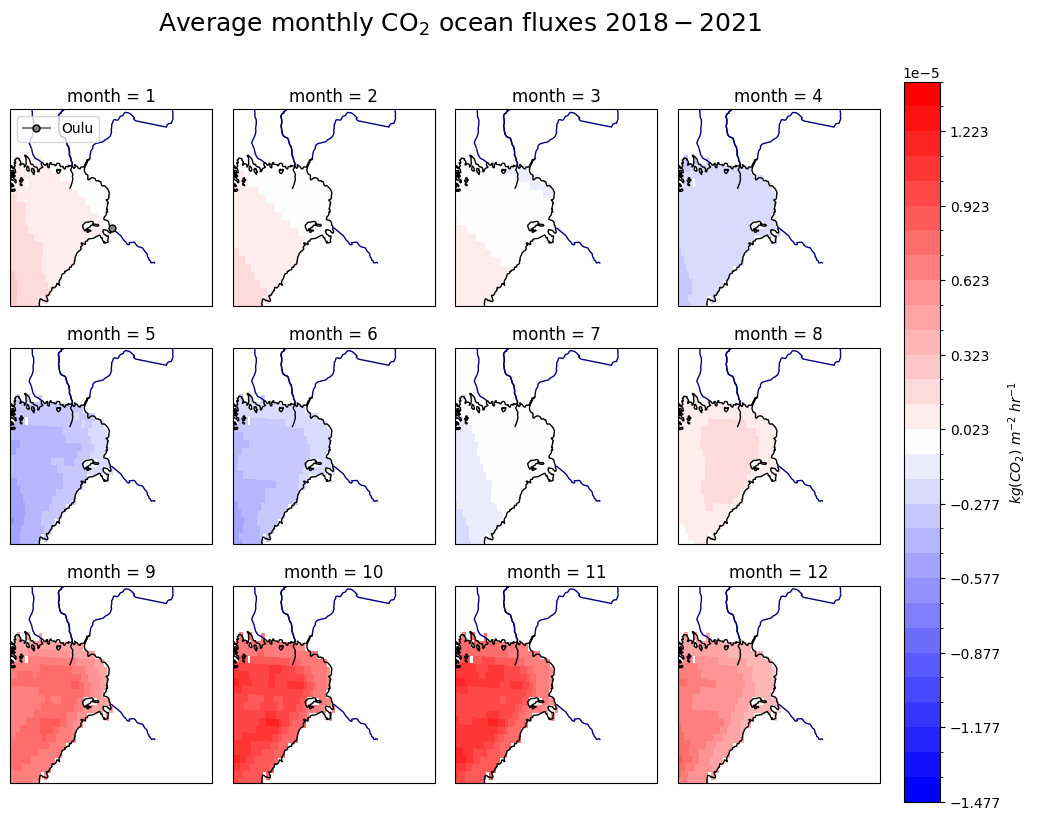

In [46]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import MultipleLocator


suptitle="Average monthly CO$_2$ ocean fluxes $2018-2021$"
cmap = mpl.colormaps["bwr"] #truncate_colormap(mpl.colormaps["seismic"], minval=0.5)
cbar_shrink = 0.9
cbar_label = "$kg(CO_2)$ $m^{-2}$ $hr^{-1}$"
extent = [22.5, 28.5, 64, 66.5]
ds = monthly_means["emi_ocn"]

# Set up the map with a Plate Carree projection
fig, axs = plt.subplots(3, 4, figsize=(12,9), subplot_kw={'projection': ccrs.epsg('3067')})
i = 1
for ax in axs.flatten():
    ax.set_extent(extent, crs=ccrs.PlateCarree())  # Central Finland area

    # Add features such as borders and coastlines
    ax.add_feature(cfeature.BORDERS, linestyle='-')
    ax.add_feature(cfeature.COASTLINE)

    # Add rivers
    ax.add_feature(cfeature.RIVERS, edgecolor='navy')

    # Add a dot for Oulu
    if i == 1:
        oulu_lat, oulu_lon = 65.0121, 25.4651  # Latitude and Longitude of Oulu
        ax.plot(oulu_lon, oulu_lat, color='grey', markeredgecolor='black', marker='o', markersize=5, label='Oulu', transform=ccrs.PlateCarree() )
        # Add a legend
        ax.legend(loc='upper left')

    mon = ds.sel(month=i)

    im = mon.where(mon!=0).plot(ax=ax, cmap=cmap, transform = ccrs.PlateCarree(), levels=np.arange(-ds.max(), ds.max(), 1e-6),
                                        add_colorbar=False)
    
    
    i += 1
# Adjust layout to make space for the colorbar
fig.subplots_adjust(right=0.85, wspace=0.1, hspace=0.1)

# Add a single colorbar for all plots

cbar_ax = fig.add_axes([0.87, 0.1, 0.03, 0.8])
#fig.colorbar(im, cax=cbar_ax)
fig.colorbar(im, label=cbar_label, cax=cbar_ax, shrink=0.6)
    
fig.suptitle(suptitle, fontsize=18)
figpath = "/home/pietaril/Documents/plots/Kiiminki/"
figname = "CO2_ocn_monthly2_Finland_Ouluregion.pdf"
#plt.savefig(os.path.join(figpath, figname))
# Show the plot
plt.show()

In [15]:
ds.max()

<xarray.DataArray 'emi_ocn' ()>
array(1.47651753e-05)

# Compute domain totals for Finland/Europe
*Need to do the comparison of domain totals between the coarse and the highres with whole Europe since Finland mask 0.1 x 0.1 deg and apparently doesn't work with the coarse data (at least not without modifications)

In [ ]:
from areagrid import areagrid

def g_per_m2_per_yr_to_Mt_per_yr(ds, var):
    
    lat = ds["latitude"].values
    lon = ds["longitude"].values


    # compute the areas of the gridcells in the data
    grid_of_areas = areagrid(lat, lon)

    # pointwise multiplication by area
    totals = ds[var] * grid_of_areas


    domain_tot = totals.sum(dim=("latitude", "longitude"))

    #g to Mt
    domain_tot = domain_tot*1e-12

    return domain_tot


def get_fin_mask(data_to_be_masked):

    """Helper function to get Finland mask with the same dimensionality
    as the data to be masked """

    MASK_PATH = "/home/pietaril/Documents/data/masks/country_masks/eez_01x01.nc4"
    ds_mask = xr.open_dataset(MASK_PATH)
    msk = ds_mask.Band1
    ds_mask.close()

    #limit the mask first to the same domain where the saved g/m2/yr values are
    latmin = data_to_be_masked["latitude"].values.min()-0.05
    latmax = data_to_be_masked["latitude"].values.max()+0.05
    lonmin = data_to_be_masked["longitude"].values.min()-0.05
    lonmax = data_to_be_masked["longitude"].values.max()+0.05
    aoi = [lonmin, lonmax, latmin, latmax]
    msk = select_area(aoi,msk)

    #Finland = 83
    msk_fin = msk==83

    #rename dimensions to match the ones in the data
    rename_map = {
        "lat": "latitude",
        "lon": "longitude",
        }
    msk_fin = msk_fin.rename(rename_map)

    #expand time dimension to match the data
    msk_fin_expanded = msk_fin.expand_dims(time=data_to_be_masked.time)

    return msk_fin_expanded

In [6]:
COARSE_PATH = "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/coarse_g_m-2_yr/"
HIGHRES_PATH =  "/home/pietaril/Documents/data/CTE_ocean_fluxes/domain_-12_35_35_72/highres_g_m-2_yr/"
totals = []
for PATH in [COARSE_PATH, HIGHRES_PATH]:


    fnames_yearly = [os.path.join(PATH, f) for f in os.listdir(PATH)]
    yearly_datasets = [xr.open_dataset(f) for f in fnames_yearly]
    #combine the yearly fluxgrids to a single dataset
    ds_allyears = xr.concat(yearly_datasets, dim="time") 
    ds_allyears = ds_allyears.sortby("time")

    #expand the mask to match the dimensions of the data
    eur_tot = g_per_m2_per_yr_to_Mt_per_yr(ds_allyears, "emi_ocn")
    totals.append(eur_tot)

totals

[<xarray.DataArray 'emi_ocn' (time: 4)>
 array([-252.33586507, -260.24589839, -270.7950489 , -252.28392362])
 Coordinates:
   * time     (time) datetime64[ns] 2018-01-01 2019-01-01 2020-01-01 2021-01-01,
 <xarray.DataArray 'emi_ocn' (time: 4)>
 array([-255.28870356, -263.8508987 , -274.25940505, -255.75866856])
 Coordinates:
   * time     (time) datetime64[ns] 2018-01-01 2019-01-01 2020-01-01 2021-01-01]

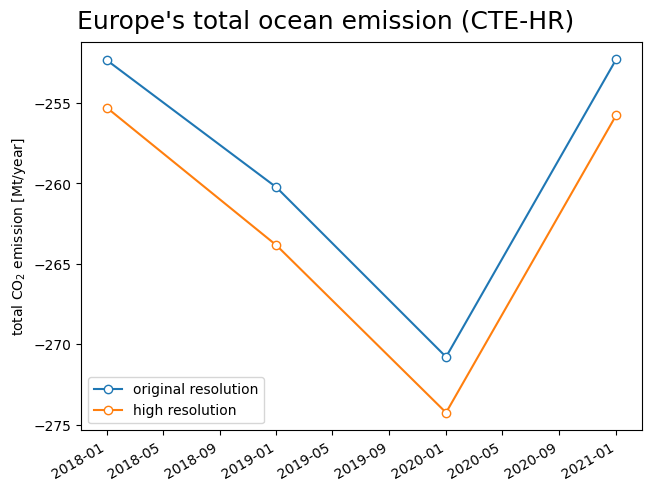

In [12]:
fig, ax = plt.subplots(layout="constrained")#, figsize=(9,6))
labels = ["original resolution", "high resolution"]

for (ind,tot) in enumerate(totals):
    data = tot
    data.plot(x="time", ax=ax, marker='.', markersize=12, markerfacecolor='white', label=labels[ind])


#Shrink current axis by 20%
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend()#loc='center left')#, bbox_to_anchor=(0.5, 0.8))
ax.set_ylabel("total CO$_2$ emission [Mt/year]")
ax.set_xlabel("")
fig.suptitle("Europe's total ocean emission (CTE-HR)", fontsize = 18 )
#plt.legend()
plt.draw()
figpath = "/home/pietaril/Documents/plots/CTE/total_emis/"
figname = f"CTE_ocean_yearly_totals_CO2.png"
#plt.savefig(figpath+figname)

# Sanity checks

In [ ]:
#check the function piece by piece

dataset = ocn_small
new_dataset = dataset.copy(deep=True)

# Extract coordinates and the variable
lat = new_dataset['latitude']
lon = new_dataset['longitude']
var = new_dataset["ocean"]

# Replace zeros with NaN for interpolation
var_with_nan = var.where(var != 0, np.nan)

# Flatten latitude, longitude, and variable values for griddata input
lon_grid, lat_grid = np.meshgrid(lon, lat)
points = np.array([lat_grid.ravel(), lon_grid.ravel()]).T
values = var_with_nan.values.ravel()

# Identify valid points (where the variable is not NaN)
valid_mask = ~np.isnan(values)
valid_points = points[valid_mask]
valid_values = values[valid_mask]

# Interpolate to fill missing (NaN) values, including extrapolation at boundaries
interpolated_values = griddata(
    valid_points, valid_values, points, method=method, fill_value=np.nan
)

# Reshape interpolated values back to the original grid shape
interpolated_grid = interpolated_values.reshape(var.shape)

# Replace zeros in the original data with interpolated values
filled_var = np.where(var == 0, interpolated_grid, var)

# Assign the modified variable to the new dataset
new_dataset["ocean"] = (var.dims, filled_var)
